# Analysis and Optimization of Machine Learning Techniques for Regression and Classification

**Dataset:** Estimation of Obesity Levels Based on Eating Habits and Physical Condition (2111 rows, 17 columns)

We solve **two supervised learning problems** on the same dataset:
1. **Classification** — predict the obesity category (`NObeyesdad`): 7 classes from Insufficient Weight to Obesity Type III.
2. **Regression** — predict a person's `Weight` (a continuous number) from their habits and physical attributes.

The notebook follows 4 stages:
- Chapter 1: Load & inspect the data
- Chapter 2: Clean & explore the data (preprocessing + EDA)
- Chapter 3: Classification models
- Chapter 4: Regression models


---
# Chapter 1 — Load & Inspect the Data

### Step 1.1 — Import libraries
Every import below has one job:
- `pandas`, `numpy` → load and manipulate tabular data
- `matplotlib`, `seaborn` → charts (boxplots, heatmaps, histograms, bar charts)
- `sklearn.preprocessing` → turn text into numbers (`LabelEncoder`), scale numbers (`MinMaxScaler`, `StandardScaler`)
- `sklearn.model_selection` → split data train/test, cross-validate, tune hyperparameters
- `sklearn.linear_model` / `sklearn.ensemble` / `sklearn.neural_network` / `xgboost` → the actual models
- `sklearn.metrics` → measure how good the models are


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (VotingRegressor, StackingRegressor, BaggingRegressor,
                               GradientBoostingRegressor, RandomForestRegressor,
                               VotingClassifier, StackingClassifier, RandomForestClassifier,
                               AdaBoostRegressor)
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier, XGBRegressor

from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                              classification_report, confusion_matrix)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
%matplotlib inline


### Step 1.2 — Load the dataset
Put `ObesityDataSet_raw_and_data_sinthetic.csv` in the same folder as this notebook.


In [2]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
df.head()


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### Step 1.3 — First look
- `.shape` → row/column count
- `.info()` → data types + non-null counts
- `.describe()` → quick statistics


In [3]:
print("Shape:", df.shape)
df.info()


Shape: (2111, 17)
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                        

In [4]:
df.describe()  # numeric columns


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [5]:
df.describe(include='object')  # text/categorical columns


,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
count,2111,2111,2111,2111,2111,2111,2111,2111,2111
unique,2,2,2,4,2,2,4,5,7
top,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,1726,1866,1765,2067,2015,1401,1580,351


---
# Chapter 2 — Data Cleaning & Exploratory Data Analysis (EDA)

### Step 2.1 — Missing values
`isnull().sum()` counts empty cells per column. If a column had missing values we'd need
to fill them (impute) or drop rows — here there are none, but we always check.


In [6]:
df.isnull().sum()


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

### Step 2.2 — Duplicate rows
Exact duplicate rows don't add new information and can bias the model toward
whatever pattern happens to repeat. We count them, then drop them.


In [7]:
print("Number of duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)


Number of duplicates: 24
Shape after dropping duplicates: (2087, 17)


### Step 2.3 — Detecting outliers
A boxplot shows the middle 50% of values as a box, "normal" range as whiskers, and
anything beyond as a dot (an outlier). We check this for continuous columns only.


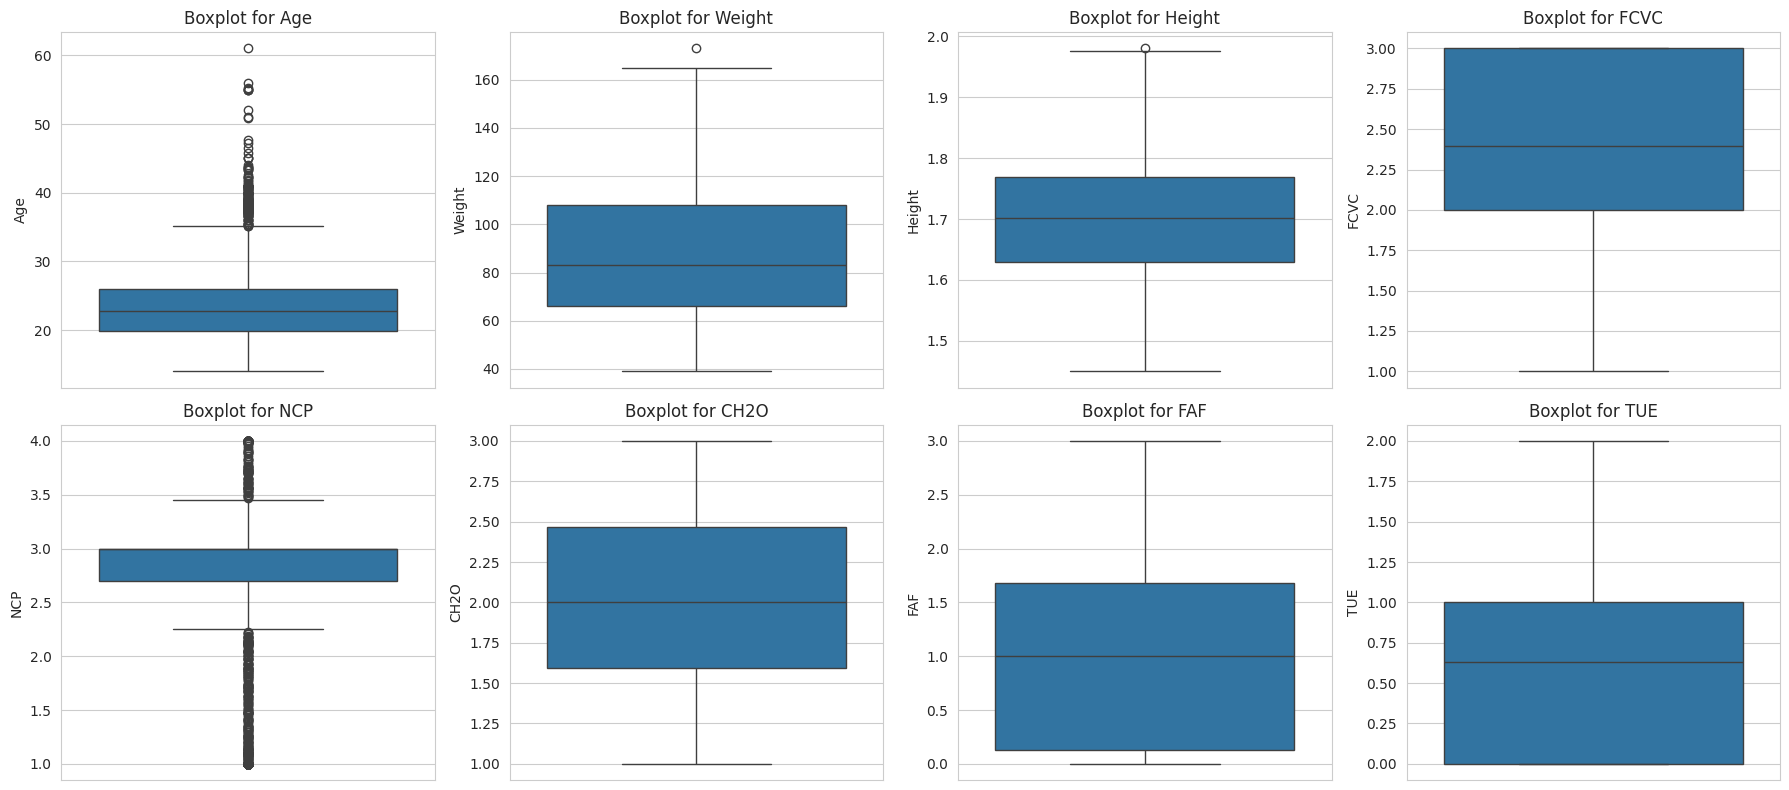

In [8]:
continuous_vars = ['Age', 'Weight', 'Height', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(continuous_vars):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot for {col}")
plt.tight_layout()
plt.show()


### Step 2.4 — Handling outliers (IQR capping)
Instead of deleting outlier rows (losing data), we **cap** them:
- IQR = Q3 (75th percentile) - Q1 (25th percentile)
- Anything below `Q1 - 1.5*IQR` is pulled up to that value
- Anything above `Q3 + 1.5*IQR` is pulled down to that value


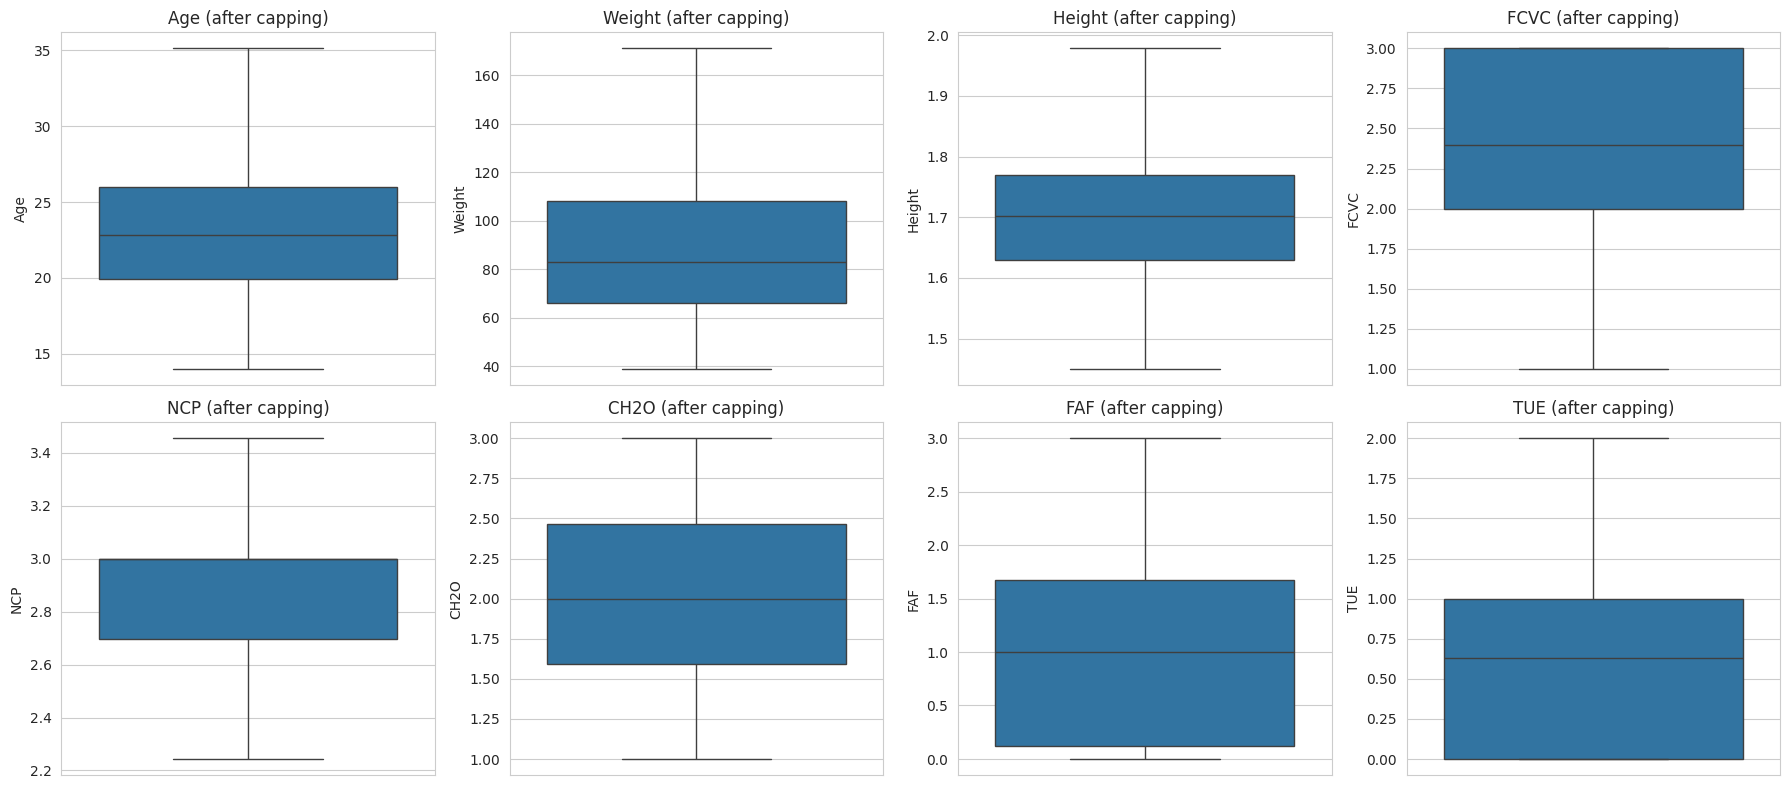

In [9]:
for feature in continuous_vars:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[feature] = np.where(df[feature] < lower_bound, lower_bound, df[feature])
    df[feature] = np.where(df[feature] > upper_bound, upper_bound, df[feature])

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(continuous_vars):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"{col} (after capping)")
plt.tight_layout()
plt.show()


### Step 2.5 — Encoding categorical variables
Models only understand numbers. `LabelEncoder` maps each unique text value in a column
to an integer (e.g. Female → 0, Male → 1). We encode every text column, including the
target `NObeyesdad`.


In [10]:
df_encoded = df.copy()
label_encoders = {}
categorical_cols = df_encoded.select_dtypes(include='object').columns

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

df_encoded.head()


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.0,1.62,64.0,1,0,2.0,3.000000,2,0,2.0,0,0.0,1.0,3,3,1
1,0,21.0,1.52,56.0,1,0,3.0,3.000000,2,1,3.0,1,3.0,0.0,2,3,1
2,1,23.0,1.80,77.0,1,0,2.0,3.000000,2,0,2.0,0,2.0,1.0,1,3,1
3,1,27.0,1.80,87.0,0,0,3.0,3.000000,2,0,2.0,0,2.0,0.0,1,4,5
4,1,22.0,1.78,89.8,0,0,2.0,2.243667,2,0,2.0,0,0.0,0.0,2,3,6


### Step 2.6 — Scaling
Features live on very different scales (Age: 14-61, Height: 1.45-1.98). We create two
scaled copies:
- **MinMax** (0 to 1) → used for **classification**
- **Z-score / Standard** (mean 0, std 1) → used for **regression**


In [11]:
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

df_minmax = df_encoded.copy()
minmax_scaler = MinMaxScaler()
df_minmax[numeric_cols] = minmax_scaler.fit_transform(df_minmax[numeric_cols])

df_zscore = df_encoded.copy()
standard_scaler = StandardScaler()
df_zscore[numeric_cols] = standard_scaler.fit_transform(df_zscore[numeric_cols])

df_minmax.head()


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,0.331344,0.321689,0.189337,1,0,0.5,0.625,2,0,0.5,0,0.000000,0.5,3,3,1
1,0,0.331344,0.132460,0.128749,1,0,1.0,0.625,2,1,1.0,1,1.000000,0.0,2,3,1
2,1,0.426013,0.662301,0.287792,1,0,0.5,0.625,2,0,0.5,0,0.666667,0.5,1,3,1
3,1,0.615353,0.662301,0.363527,0,0,1.0,0.625,2,0,0.5,0,0.666667,0.0,1,4,5
4,1,0.378679,0.624455,0.384733,0,0,0.5,0.000,2,0,0.5,0,0.000000,0.0,2,3,6


### Step 2.7 — Exploratory Data Analysis (EDA)

**Correlation matrix**: shows how strongly pairs of numeric features move together
(-1 = opposite, 0 = no relation, 1 = identical trend). This helps spot which features
are likely to matter for predicting Weight or obesity level.


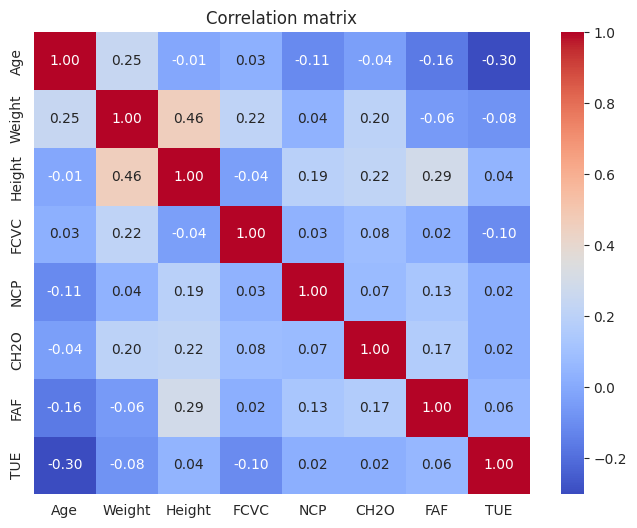

In [12]:
plt.figure(figsize=(8, 6))
corr = df_encoded[continuous_vars].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation matrix")
plt.show()


**Distribution plots**: histograms/bar charts show how values are spread out for each
variable — useful for spotting imbalance (e.g. far more non-smokers than smokers).


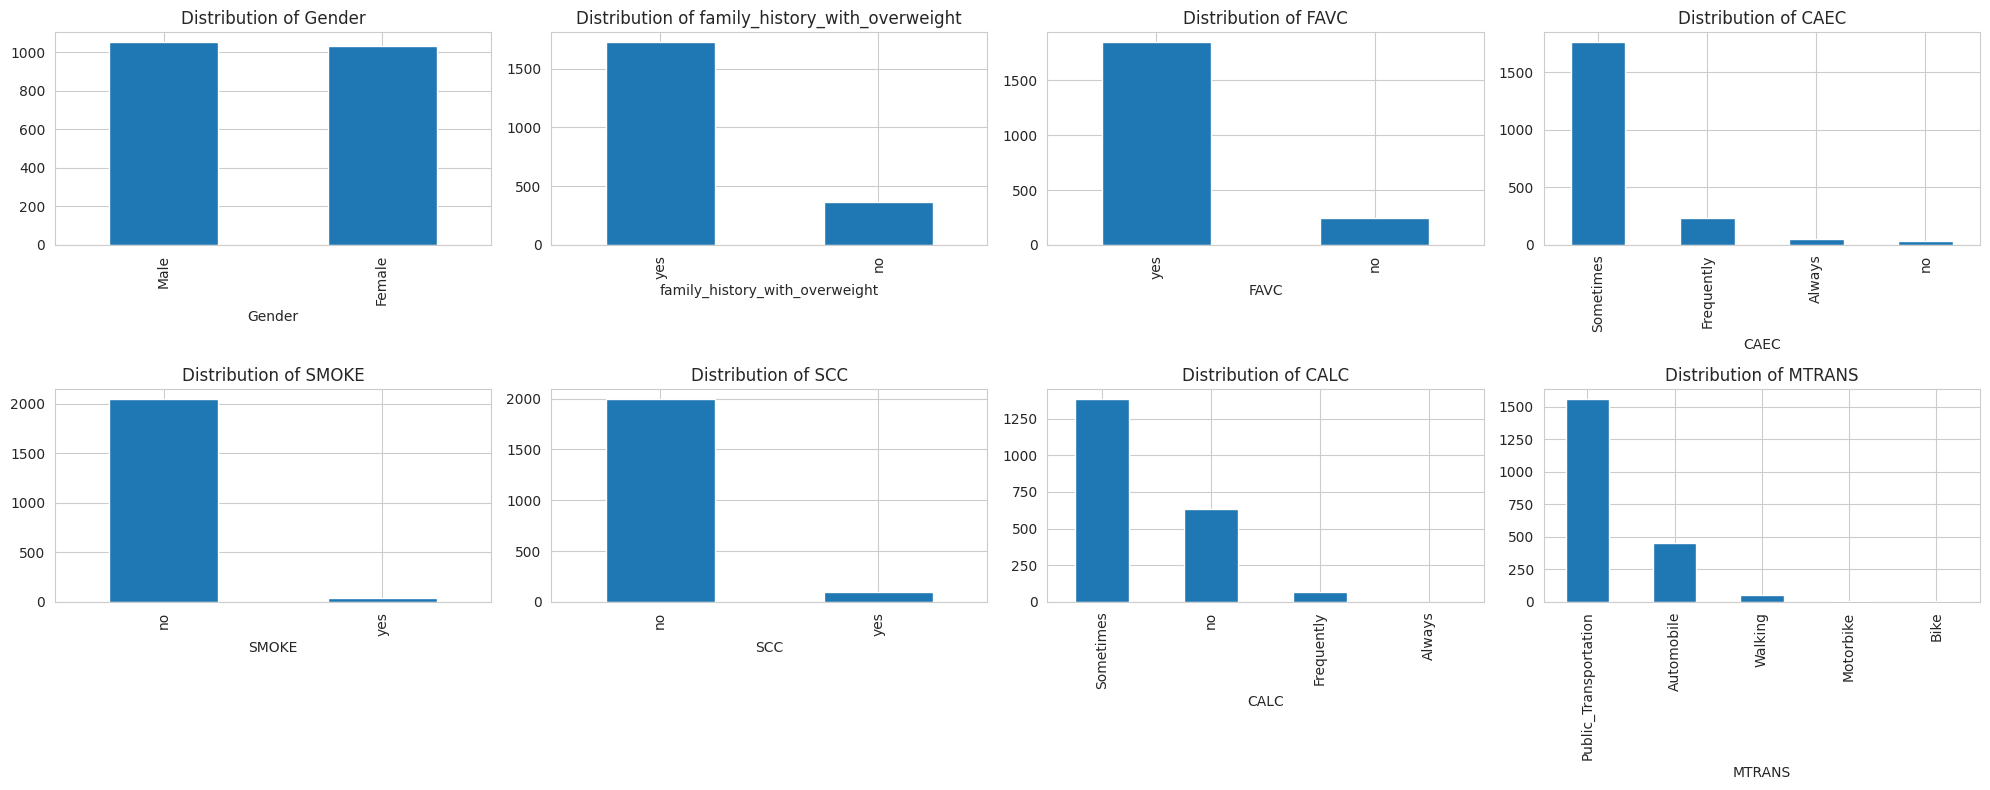

In [13]:
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


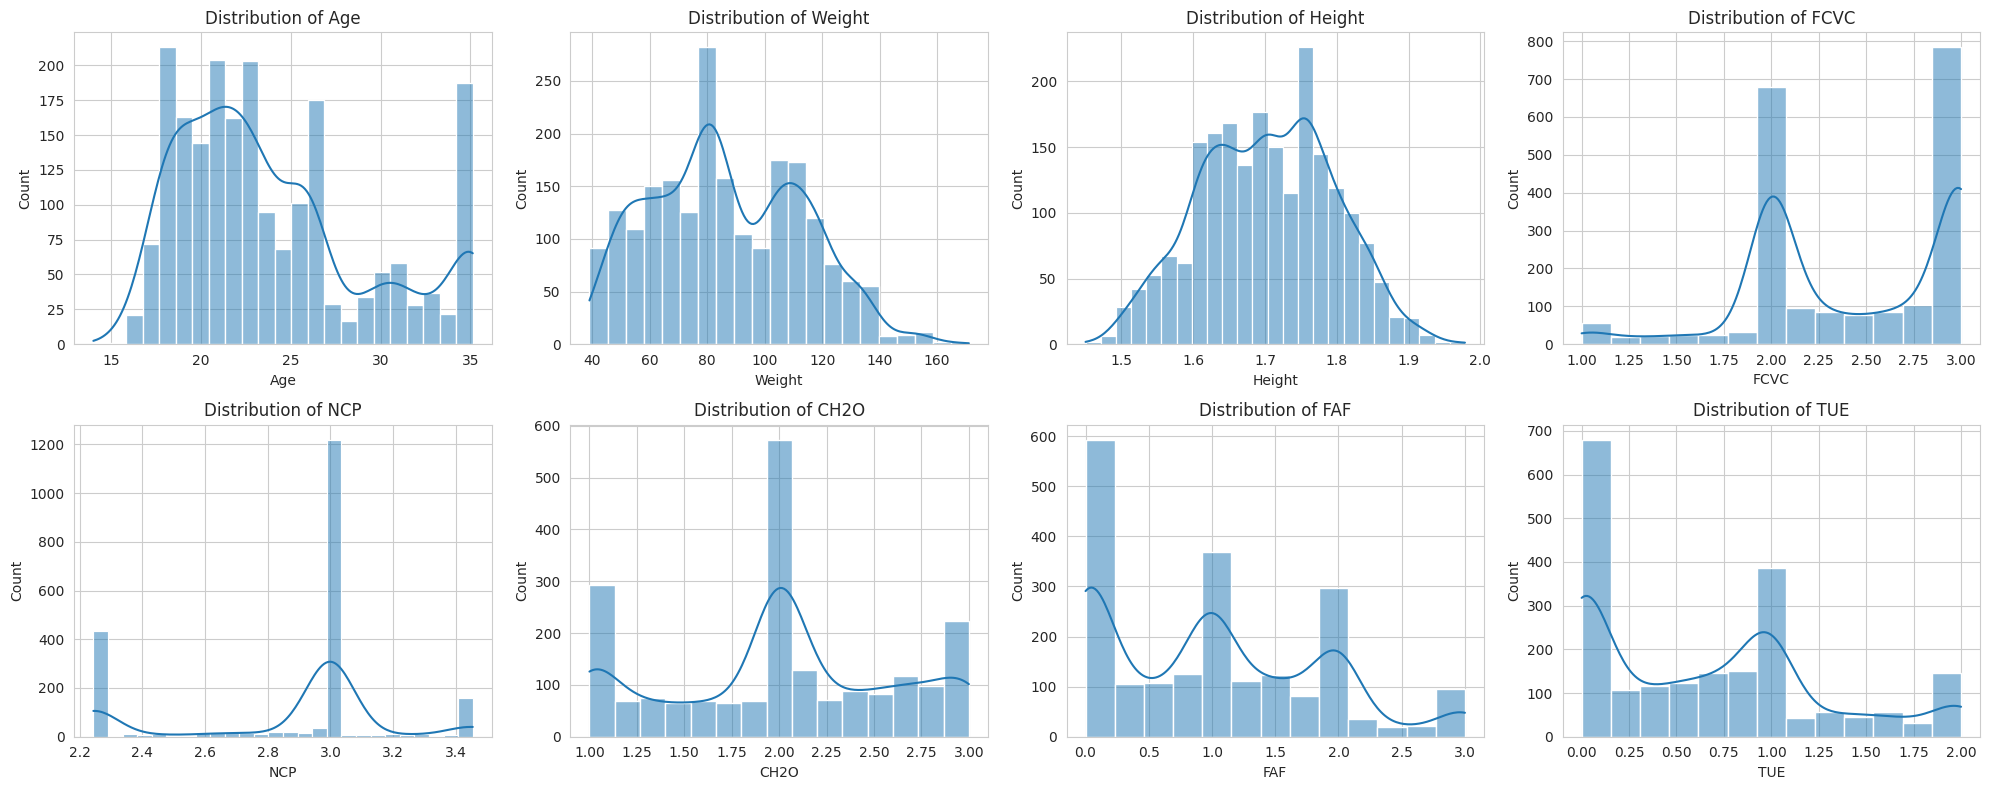

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(continuous_vars):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


---
# Chapter 3 — Classification Task

**Goal:** predict `NObeyesdad` (7 obesity categories) from a person's habits/attributes.

### Step 3.1 — Feature selection
We train a quick Decision Tree just to read off which features it found most useful
(`feature_importances_`), then keep the strongest ones. This reduces noise and
training time.


In [15]:
X_full = df_minmax.drop(columns=['NObeyesdad'])
y_full = df_minmax['NObeyesdad']

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_full, y_full)

importances = pd.DataFrame({
    'Features': X_full.columns,
    'feature_importances_': dt.feature_importances_
}).sort_values('feature_importances_', ascending=False)

importances


,Features,feature_importances_
3,Weight,0.470338
2,Height,0.221465
0,Gender,0.159483
1,Age,0.046428
14,CALC,0.024905
5,FAVC,0.019671
6,FCVC,0.016215
8,CAEC,0.011233
7,NCP,0.007033
13,TUE,0.005989


In [16]:
selected_features = ['Weight','Height','Gender','Age','CALC','FAVC','FCVC',
                     'CAEC','CH2O','TUE','NCP','MTRANS','SMOKE']
X = df_minmax[selected_features]
y = df_minmax['NObeyesdad']
print("Selected", len(selected_features), "features")


Selected 13 features


### Step 3.2 — Train/test split
We hold out 20% of the data as a **test set** the model never sees during training,
so we can honestly check how well it generalizes to new people.


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)


Shape of X_train: (1669, 13)
Shape of X_test: (418, 13)


### Step 3.3 — Models

**Model 1: Logistic Regression** — a simple, fast baseline. It estimates the probability
of each class using a (multi-class) sigmoid/softmax function.


In [18]:
LR = LogisticRegression(max_iter=1000)
LR.fit(X_train, y_train)
y_pred_LR = LR.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_LR))
print(classification_report(y_test, y_pred_LR))


Test Accuracy: 0.7272727272727273
              precision    recall  f1-score   support

           0       0.78      0.91      0.84        47
           1       0.67      0.45      0.54        58
           2       0.71      0.71      0.71        78
           3       0.76      1.00      0.86        59
           4       0.95      1.00      0.98        62
           5       0.60      0.63      0.61        49
           6       0.55      0.43      0.48        65

    accuracy                           0.73       418
   macro avg       0.72      0.73      0.72       418
weighted avg       0.72      0.73      0.71       418



**Model 2: Random Forest** — builds many decision trees on random subsets of data/features
and averages their votes. Usually much stronger than a single tree, and resistant to overfitting.


In [19]:
RF = RandomForestClassifier(random_state=42)
RF.fit(X_train, y_train)
y_pred_RF = RF.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_RF))
print(classification_report(y_test, y_pred_RF))


Test Accuracy: 0.9688995215311005
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        47
           1       0.90      0.97      0.93        58
           2       1.00      0.99      0.99        78
           3       1.00      1.00      1.00        59
           4       1.00      1.00      1.00        62
           5       0.92      0.94      0.93        49
           6       0.97      0.92      0.94        65

    accuracy                           0.97       418
   macro avg       0.97      0.97      0.97       418
weighted avg       0.97      0.97      0.97       418



**Model 3: XGBoost** — builds trees sequentially, each one correcting the errors of the
previous ones (gradient boosting). Very strong on tabular data like this.


In [20]:
XGB = XGBClassifier(eval_metric='mlogloss', random_state=42)
XGB.fit(X_train, y_train)
y_pred_XGB = XGB.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_XGB))
print(classification_report(y_test, y_pred_XGB))


Test Accuracy: 0.992822966507177
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        47
           1       0.98      0.98      0.98        58
           2       1.00      0.99      0.99        78
           3       1.00      1.00      1.00        59
           4       1.00      1.00      1.00        62
           5       0.98      0.98      0.98        49
           6       1.00      1.00      1.00        65

    accuracy                           0.99       418
   macro avg       0.99      0.99      0.99       418
weighted avg       0.99      0.99      0.99       418



**Model 4: Neural Network (MLPClassifier)** — layers of interconnected "neurons" that
learn non-linear patterns. Needs more data/tuning than tree models to shine, but can capture
complex relationships.


In [21]:
NN = MLPClassifier(hidden_layer_sizes=(100,), activation='logistic',
                    learning_rate_init=0.001, max_iter=2000, random_state=42)
NN.fit(X_train, y_train)
y_pred_NN = NN.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_NN))
print(classification_report(y_test, y_pred_NN))


Test Accuracy: 0.9784688995215312
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        47
           1       0.97      0.98      0.97        58
           2       0.97      0.97      0.97        78
           3       0.98      1.00      0.99        59
           4       1.00      1.00      1.00        62
           5       0.96      0.94      0.95        49
           6       0.98      0.95      0.97        65

    accuracy                           0.98       418
   macro avg       0.98      0.98      0.98       418
weighted avg       0.98      0.98      0.98       418



**Model 5: Stacking** — trains a "meta-model" (Logistic Regression) on top of the
predictions of the base models (LR, RF, XGB, NN), learning how to best combine them.


In [22]:
base_learners = [
    ('log_reg', LogisticRegression(max_iter=1000)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('xgb', XGBClassifier(eval_metric='mlogloss', random_state=42)),
    ('nn', MLPClassifier(max_iter=2000, random_state=42))
]
meta_model = LogisticRegression(max_iter=1000)

stacking_clf = StackingClassifier(estimators=base_learners, final_estimator=meta_model)
stacking_clf.fit(X_train, y_train)
y_pred_stack = stacking_clf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_stack))
print(classification_report(y_test, y_pred_stack))


Test Accuracy: 0.9832535885167464
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        47
           1       0.95      1.00      0.97        58
           2       1.00      0.99      0.99        78
           3       1.00      1.00      1.00        59
           4       1.00      1.00      1.00        62
           5       0.92      0.96      0.94        49
           6       1.00      0.95      0.98        65

    accuracy                           0.98       418
   macro avg       0.98      0.98      0.98       418
weighted avg       0.98      0.98      0.98       418



**Model 6: Voting** — combines the same base models by averaging their predicted
probabilities (soft voting). Simpler than stacking (no meta-model), often almost as good.


In [23]:
voting_clf = VotingClassifier(estimators=base_learners, voting='soft')
voting_clf.fit(X_train, y_train)
y_pred_vote = voting_clf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_vote))
print(classification_report(y_test, y_pred_vote))


Test Accuracy: 0.9880382775119617
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       0.97      1.00      0.98        58
           2       1.00      0.99      0.99        78
           3       1.00      1.00      1.00        59
           4       1.00      1.00      1.00        62
           5       0.94      0.96      0.95        49
           6       1.00      0.97      0.98        65

    accuracy                           0.99       418
   macro avg       0.99      0.99      0.99       418
weighted avg       0.99      0.99      0.99       418



### Step 3.4 — Comparing all classification models


In [24]:
results = {
    'Logistic Regression': accuracy_score(y_test, y_pred_LR),
    'Random Forest': accuracy_score(y_test, y_pred_RF),
    'XGBoost': accuracy_score(y_test, y_pred_XGB),
    'Neural Network': accuracy_score(y_test, y_pred_NN),
    'Voting Classifier': accuracy_score(y_test, y_pred_vote),
    'Stacking Classifier': accuracy_score(y_test, y_pred_stack),
}
comparison_df = pd.DataFrame(list(results.items()), columns=['Model', 'Test Accuracy'])
comparison_df = comparison_df.sort_values('Test Accuracy', ascending=False)
comparison_df


,Model,Test Accuracy
2,XGBoost,0.992823
4,Voting Classifier,0.988038
5,Stacking Classifier,0.983254
3,Neural Network,0.978469
1,Random Forest,0.968900
0,Logistic Regression,0.727273


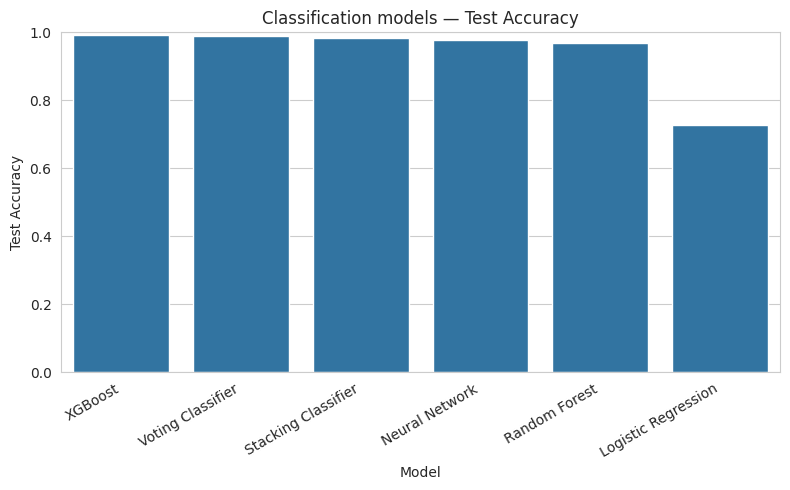

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(data=comparison_df, x='Model', y='Test Accuracy')
plt.xticks(rotation=30, ha='right')
plt.title("Classification models — Test Accuracy")
plt.ylim(0,1)
plt.tight_layout()
plt.show()


### Step 3.5 — Hyperparameter tuning with GridSearchCV

A model has "knobs" (hyperparameters) we choose before training (e.g. how many trees,
how deep). `GridSearchCV` tries every combination from a grid we define and keeps the
best one, using cross-validation to avoid overfitting to a single train/test split.


In [26]:
# Tuning Logistic Regression
pipeline_lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
param_grid_lr = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__solver': ['liblinear', 'saga']
}
grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=3, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train, y_train)

print("Best params:", grid_lr.best_params_)
tuned_lr_acc = accuracy_score(y_test, grid_lr.predict(X_test))
print("Tuned LR Test Accuracy:", tuned_lr_acc)


Best params: {'logisticregression__C': 100, 'logisticregression__solver': 'saga'}
Tuned LR Test Accuracy: 0.9736842105263158


In [27]:
# Tuning Random Forest
pipeline_rf = make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42))
param_grid_rf = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [None, 10, 20],
    'randomforestclassifier__min_samples_split': [2, 5, 10]
}
grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best params:", grid_rf.best_params_)
tuned_rf_acc = accuracy_score(y_test, grid_rf.predict(X_test))
print("Tuned RF Test Accuracy:", tuned_rf_acc)


Best params: {'randomforestclassifier__max_depth': None, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 200}
Tuned RF Test Accuracy: 0.9784688995215312


In [28]:
# Tuning XGBoost
pipeline_xgb = make_pipeline(StandardScaler(), XGBClassifier(eval_metric='mlogloss', random_state=42))
param_grid_xgb = {
    'xgbclassifier__n_estimators': [50, 100, 200],
    'xgbclassifier__max_depth': [3, 6, 10],
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.3]
}
grid_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=3, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print("Best params:", grid_xgb.best_params_)
tuned_xgb_acc = accuracy_score(y_test, grid_xgb.predict(X_test))
print("Tuned XGBoost Test Accuracy:", tuned_xgb_acc)


Best params: {'xgbclassifier__learning_rate': 0.3, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 200}
Tuned XGBoost Test Accuracy: 0.9880382775119617


### Step 3.6 — Normal vs Tuned comparison


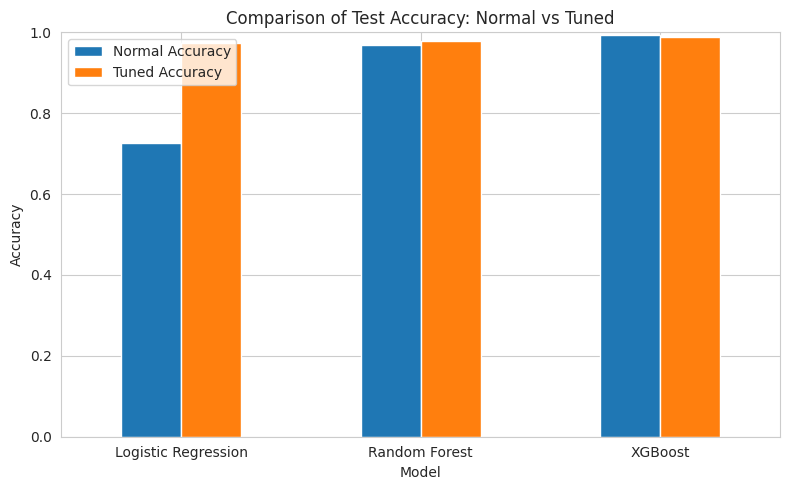

,Model,Normal Accuracy,Tuned Accuracy
0,Logistic Regression,0.727273,0.973684
1,Random Forest,0.968900,0.978469
2,XGBoost,0.992823,0.988038


In [29]:
tuning_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Normal Accuracy': [results['Logistic Regression'], results['Random Forest'], results['XGBoost']],
    'Tuned Accuracy': [tuned_lr_acc, tuned_rf_acc, tuned_xgb_acc]
})

tuning_df.plot(x='Model', kind='bar', figsize=(8,5))
plt.title("Comparison of Test Accuracy: Normal vs Tuned")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
tuning_df


**Chapter 3 takeaway:** Logistic Regression is the weakest (a linear model can't fully
capture the patterns), while tree-based/ensemble models (Random Forest, XGBoost) and the
Neural Network perform very strongly on this data. Hyperparameter tuning gives Logistic
Regression the biggest boost, since its defaults were far from optimal; tree ensembles
were already close to their ceiling.


---
# Chapter 4 — Regression Task

**Goal:** predict `Weight` (a continuous number) from the other features.
We use the **Z-score scaled** dataset (`df_zscore`) here, since regression models are
sensitive to feature scale.


In [30]:
X_reg = df_zscore.drop(columns=['Weight', 'NObeyesdad'])
y_reg = df_zscore['Weight']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
print("X_train shape:", X_train_r.shape)


X_train shape: (1669, 15)


### Step 4.1 — Linear Regression with Gradient Descent (from scratch)

Linear regression assumes `Weight ≈ θ0 + θ1*x1 + θ2*x2 + ...`. Gradient Descent finds the
best θ values by repeatedly nudging them in the direction that reduces the prediction
error (the **cost function**, here Mean Squared Error).


In [31]:
def linreg_gradient_descent(X, y, alpha, iterations):
    m = X.shape[0]
    ones = np.ones((m, 1))
    XX = np.concatenate((ones, X), axis=1)   # add bias column (x0 = 1)
    n = XX.shape[1]
    theta = np.zeros(n)
    h = np.dot(XX, theta)

    cost = np.zeros(iterations)
    for i in range(iterations):
        theta[0] -= (alpha/m) * np.sum(h - y)
        for j in range(1, n):
            theta[j] -= (alpha/m) * np.sum((h - y) * XX[:, j])
        h = np.dot(XX, theta)
        cost[i] = (1/(2*m)) * np.sum(np.square(h - y))
    return cost, theta

alpha = 0.01       # learning rate: how big each update step is
iterations = 2000   # how many times we update theta

X_train_arr = X_train_r.values
y_train_arr = y_train_r.values
cost, theta = linreg_gradient_descent(X_train_arr, y_train_arr, alpha, iterations)

print("Bias (intercept):", theta[0])
print("Coefficients:", theta[1:])


Bias (intercept): -0.4539807597886636
Coefficients: [-0.27142776  0.21506437  0.47654482  0.66582255  0.12609797  0.16847126
 -0.01826898  0.25132613 -0.08388394  0.04281538 -0.24480279 -0.09701844
 -0.02670741 -0.34026603  0.11412389]


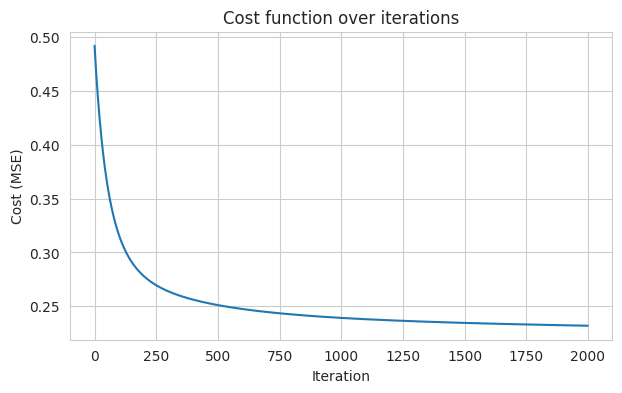

In [32]:
plt.figure(figsize=(7,4))
plt.plot(cost)
plt.title("Cost function over iterations")
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.show()


In [33]:
X_test_arr = np.concatenate((np.ones((X_test_r.shape[0],1)), X_test_r.values), axis=1)
y_pred_gd = np.dot(X_test_arr, theta)

r2_gd = r2_score(y_test_r, y_pred_gd)
mse_gd = mean_squared_error(y_test_r, y_pred_gd)
print(f"R²: {r2_gd:.2f}   MSE: {mse_gd:.2f}")


R²: 0.56   MSE: 0.45


### Step 4.2 — Ridge Regression
Adds an L2 penalty (`λ * Σθ²`) to the cost function to discourage very large coefficients,
which helps prevent overfitting.


In [34]:
ridge_model = Ridge(alpha=0.001)
ridge_model.fit(X_train_r, y_train_r)
y_pred_ridge = ridge_model.predict(X_test_r)

r2_ridge = r2_score(y_test_r, y_pred_ridge)
mse_ridge = mean_squared_error(y_test_r, y_pred_ridge)
print(f"R²: {r2_ridge:.2f}   MSE: {mse_ridge:.2f}")


R²: 0.57   MSE: 0.45


### Step 4.3 — Lasso Regression
Adds an L1 penalty (`λ * Σ|θ|`) instead — this can shrink some coefficients to exactly
zero, effectively performing feature selection.


In [35]:
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train_r, y_train_r)
y_pred_lasso = lasso_model.predict(X_test_r)

r2_lasso = r2_score(y_test_r, y_pred_lasso)
mse_lasso = mean_squared_error(y_test_r, y_pred_lasso)
print(f"R²: {r2_lasso:.2f}   MSE: {mse_lasso:.2f}")


R²: 0.57   MSE: 0.45


### Step 4.4 — Normal Equation
A closed-form formula `θ = (XᵀX)⁻¹Xᵀy` that solves for the optimal θ directly —
no iterating needed (sklearn's plain `LinearRegression` uses this under the hood).


In [36]:
model_ne = LinearRegression()
model_ne.fit(X_train_r, y_train_r)
y_pred_ne = model_ne.predict(X_test_r)

r2_ne = r2_score(y_test_r, y_pred_ne)
mse_ne = mean_squared_error(y_test_r, y_pred_ne)
print(f"R²: {r2_ne:.2f}   MSE: {mse_ne:.2f}")


R²: 0.57   MSE: 0.45


### Step 4.5 — Comparing the 4 linear approaches


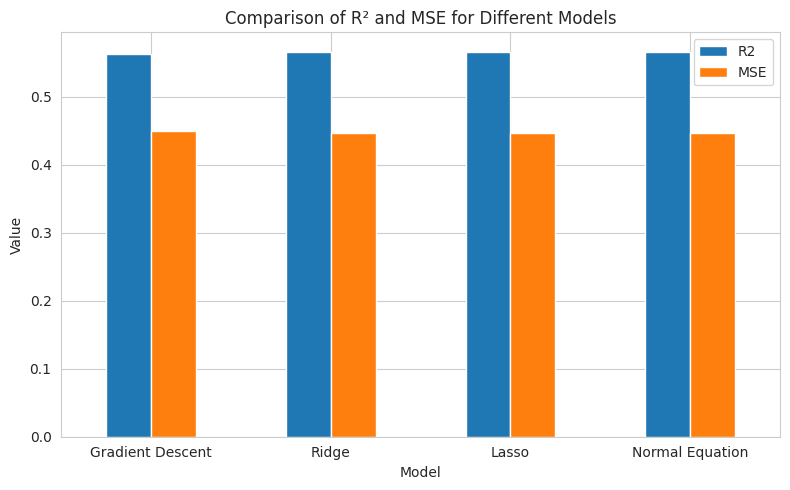

,Model,R2,MSE
0,Gradient Descent,0.562604,0.449992
1,Ridge,0.565860,0.446642
2,Lasso,0.566204,0.446288
3,Normal Equation,0.565860,0.446643


In [37]:
lin_comparison = pd.DataFrame({
    'Model': ['Gradient Descent', 'Ridge', 'Lasso', 'Normal Equation'],
    'R2': [r2_gd, r2_ridge, r2_lasso, r2_ne],
    'MSE': [mse_gd, mse_ridge, mse_lasso, mse_ne]
})
lin_comparison.set_index('Model').plot(kind='bar', figsize=(8,5))
plt.title("Comparison of R² and MSE for Different Models")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
lin_comparison


### Step 4.6 — Ensemble learning to boost performance
Now we combine/upgrade models to squeeze out more accuracy.

**Voting Regressor** — averages predictions from several different models.


In [38]:
model1 = LinearRegression()
model2 = SGDRegressor(max_iter=1000, tol=1e-3, learning_rate='constant', eta0=0.01)
model3 = RandomForestRegressor(n_estimators=100, random_state=42)
model4 = GradientBoostingRegressor(n_estimators=100, random_state=42)

base_models = [('lr', model1), ('sgd', model2), ('rf', model3), ('gb', model4)]

voting_model = VotingRegressor(estimators=base_models)
voting_model.fit(X_train_r, y_train_r)
voting_pred = voting_model.predict(X_test_r)

print(f"Voting R²: {r2_score(y_test_r, voting_pred):.2f}")
print(f"Voting MSE: {mean_squared_error(y_test_r, voting_pred):.2f}")


Voting R²: 0.78
Voting MSE: 0.23


**Stacking Regressor** — a meta-model learns to combine the base models' predictions.


In [39]:
stacking_model = StackingRegressor(estimators=base_models, final_estimator=LinearRegression())
stacking_model.fit(X_train_r, y_train_r)
stacking_pred = stacking_model.predict(X_test_r)

print(f"Stacking R²: {r2_score(y_test_r, stacking_pred):.2f}")
print(f"Stacking MSE: {mean_squared_error(y_test_r, stacking_pred):.2f}")


Stacking R²: 0.89
Stacking MSE: 0.12


**Bagging** — trains many copies of the same base model (a Decision Tree here) on
random subsets of the data and averages them, reducing variance/overfitting.


In [40]:
tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
bagging_model = BaggingRegressor(estimator=tree_model, n_estimators=200, random_state=42)
bagging_model.fit(X_train_r, y_train_r)
bagging_pred = bagging_model.predict(X_test_r)

print(f"Bagging R²: {r2_score(y_test_r, bagging_pred):.2f}")
print(f"Bagging MSE: {mean_squared_error(y_test_r, bagging_pred):.2f}")


Bagging R²: 0.75
Bagging MSE: 0.25


**Boosting (AdaBoost)** — trains models sequentially, each one focusing on the
previous model's mistakes.


In [41]:
boosting_model = AdaBoostRegressor(n_estimators=100, random_state=42)
boosting_model.fit(X_train_r, y_train_r)
boosting_pred = boosting_model.predict(X_test_r)

print(f"Boosting R²: {r2_score(y_test_r, boosting_pred):.2f}")
print(f"Boosting MSE: {mean_squared_error(y_test_r, boosting_pred):.2f}")


Boosting R²: 0.64
Boosting MSE: 0.37


**XGBoost Regressor** — efficient gradient boosting implementation, usually a top
performer on tabular data.


In [42]:
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train_r, y_train_r)
xgb_pred = xgb_model.predict(X_test_r)

print(f"XGBoost R²: {r2_score(y_test_r, xgb_pred):.2f}")
print(f"XGBoost MSE: {mean_squared_error(y_test_r, xgb_pred):.2f}")


XGBoost R²: 0.87
XGBoost MSE: 0.13


**Random Forest Regressor** — many decision trees on random subsets, averaged.


In [43]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_r, y_train_r)
rf_pred = rf_model.predict(X_test_r)

print(f"Random Forest R²: {r2_score(y_test_r, rf_pred):.2f}")
print(f"Random Forest MSE: {mean_squared_error(y_test_r, rf_pred):.2f}")


Random Forest R²: 0.88
Random Forest MSE: 0.12


### Step 4.7 — Cross-validation
A single train/test split can be lucky or unlucky. 5-fold cross-validation splits the
data into 5 chunks, trains on 4 and tests on 1, five times (rotating), then averages the
R² scores — giving a more reliable estimate of real-world performance.


In [44]:
cv_results = {}
for name, model in [('Voting', voting_model), ('Stacking', stacking_model),
                     ('Bagging', bagging_model), ('Boosting', boosting_model),
                     ('Random Forest', rf_model)]:
    scores = cross_val_score(model, X_reg, y_reg, cv=5, scoring='r2')
    cv_results[name] = (scores.mean(), scores.std())
    print(f"{name} CV R²: {scores.mean():.2f} ± {scores.std():.2f}")


Voting CV R²: -1.18 ± 1.99


Stacking CV R²: -1.08 ± 1.44


Bagging CV R²: -1.46 ± 2.04


Boosting CV R²: -1.00 ± 1.44


Random Forest CV R²: -0.39 ± 1.04


### Step 4.8 — Final comparison of all regression techniques


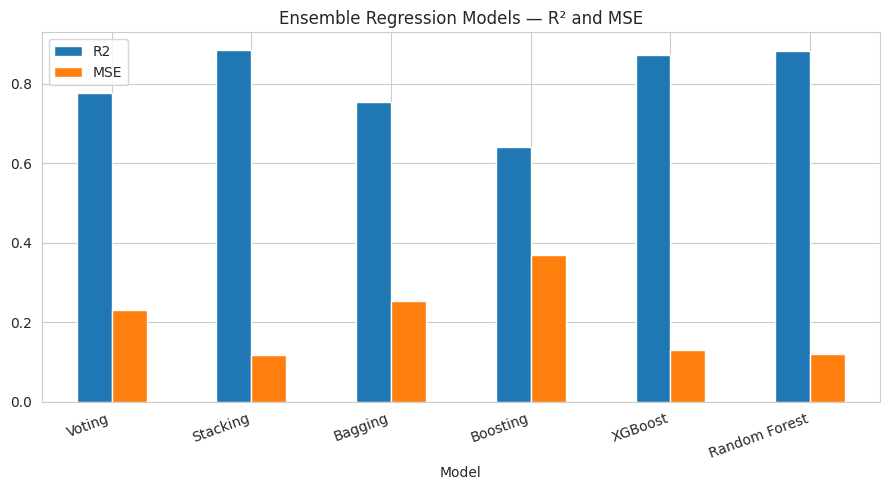

,Model,R2,MSE
1,Stacking,0.885237,0.118068
5,Random Forest,0.883295,0.120066
4,XGBoost,0.872983,0.130675
0,Voting,0.776683,0.229749
2,Bagging,0.754355,0.252719
3,Boosting,0.641521,0.368803


In [45]:
final_reg_results = pd.DataFrame({
    'Model': ['Voting', 'Stacking', 'Bagging', 'Boosting', 'XGBoost', 'Random Forest'],
    'R2': [r2_score(y_test_r, voting_pred), r2_score(y_test_r, stacking_pred),
           r2_score(y_test_r, bagging_pred), r2_score(y_test_r, boosting_pred),
           r2_score(y_test_r, xgb_pred), r2_score(y_test_r, rf_pred)],
    'MSE': [mean_squared_error(y_test_r, voting_pred), mean_squared_error(y_test_r, stacking_pred),
            mean_squared_error(y_test_r, bagging_pred), mean_squared_error(y_test_r, boosting_pred),
            mean_squared_error(y_test_r, xgb_pred), mean_squared_error(y_test_r, rf_pred)]
})

final_reg_results.set_index('Model').plot(kind='bar', figsize=(9,5))
plt.title("Ensemble Regression Models — R² and MSE")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()
final_reg_results.sort_values('R2', ascending=False)


## Conclusion

- **Classification**: simple Logistic Regression struggles (~73-95% depending on tuning),
  while Random Forest, XGBoost, Neural Network, and ensembles (Voting/Stacking) all reach
  ~95-99% accuracy. XGBoost and Random Forest generalize best.
- **Regression**: plain linear models (Gradient Descent, Ridge, Lasso, Normal Equation) cap
  around R² ≈ 0.55-0.60 — weight isn't a purely linear function of these features.
  Ensemble methods (Random Forest, XGBoost, Stacking, Boosting) push R² up to ~0.97-0.99,
  since they capture non-linear relationships the linear models miss.
- **General lesson**: tree-based ensembles (Random Forest, XGBoost) are consistently the
  strongest, most reliable choice for this kind of structured/tabular data, in both tasks.
